In [1]:
import os

# Find your dataset root
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root.replace("/kaggle/input", "").count(os.sep)
    if depth > 3:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth <= 2:
        for f in files:
            print(f"{indent}  {f}")

input/
  models/
    georgelukaanya/
      quantised-hospinav-int8-onxx/
  datasets/
    akangaandrew/
      hospinav/


In [2]:
!pip install ultralytics onnxruntime-gpu -q

import onnxruntime as ort
import numpy as np
import cv2
import time
import yaml
from pathlib import Path

print("ORT version  :", ort.__version__)
print("Providers    :", ort.get_available_providers())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 7.4 MB/s eta 0:00:00
ORT version  : 1.24.4
Providers    : ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [3]:
# ── Only edit these two lines ──────────────────────────────────
ONNX_PATH    = "/kaggle/input/models/georgelukaanya/quantised-hospinav-int8-onxx/onnx/default/1/best_int8.onnx"
DATASET_ROOT = "/kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8"
# ───────────────────────────────────────────────────────────────

VAL_IMAGES = f"{DATASET_ROOT}/valid/images"
VAL_LABELS = f"{DATASET_ROOT}/valid/labels"
YAML_PATH  = f"{DATASET_ROOT}/data.yaml"

# Read class names directly from your yaml
with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg["names"]   # already a list in your yaml
NC          = len(CLASS_NAMES)

print(f"data.yaml found  : {YAML_PATH}")
print(f"Classes ({NC})   : {CLASS_NAMES}")
print(f"val images folder: {VAL_IMAGES}")
print(f"Exists           : {Path(VAL_IMAGES).exists()}")

img_paths = sorted(Path(VAL_IMAGES).glob("*.jpg")) + \
            sorted(Path(VAL_IMAGES).glob("*.png"))
print(f"Validation images: {len(img_paths)}")

data.yaml found  : /kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/data.yaml
Classes (8)   : ['Monitor', 'Saline Stand', 'bed', 'bin', 'chair', 'sofa', 'stool', 'tools_table']
val images folder: /kaggle/input/datasets/akangaandrew/hospinav/Hospital.v1-hospitaldata.yolov8/valid/images
Exists           : True
Validation images: 272


In [4]:
providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
sess = ort.InferenceSession(ONNX_PATH, providers=providers)

inp = sess.get_inputs()[0]
out = sess.get_outputs()[0]

print(f"Running on  : {sess.get_providers()[0]}")
print(f"Input  name : {inp.name}")
print(f"Input  shape: {inp.shape}   (expect [1, 3, 640, 640])")
print(f"Output shape: {out.shape}   (expect [1, 12, 8400] for 8 classes)")

INPUT_NAME = inp.name
IMG_SIZE   = inp.shape[2] if isinstance(inp.shape[2], int) else 640

Running on  : CUDAExecutionProvider
Input  name : images
Input  shape: [1, 3, 640, 640]   (expect [1, 3, 640, 640])
Output shape: [1, 12, 8400]   (expect [1, 12, 8400] for 8 classes)


2026-04-20 14:23:59.195527498 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 185 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.


In [5]:
# ── Config ──────────────────────────────────────────────────────
CONF_THRESH = 0.35   # same as your production threshold
IOU_THRESH  = 0.50   # for TP matching against GT
NMS_THRESH  = 0.45   # for suppressing duplicate predictions

def preprocess(img_path):
    img = cv2.imread(str(img_path))
    h0, w0 = img.shape[:2]
    resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    rgb     = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    blob    = rgb.astype(np.float32) / 255.0
    blob    = np.transpose(blob, (2, 0, 1))[np.newaxis]  # 1,3,H,W
    return blob, h0, w0

def parse_detections(raw_output, h0, w0):
    """
    YOLOv8 INT8 ONNX output: (1, 12, 8400)
    Box coords are in absolute pixels relative to IMG_SIZE (640x640).
    """
    preds = raw_output[0].T          # (8400, 12)
    boxes_raw  = preds[:, :4]        # cx, cy, w, h  in 640-space
    cls_scores = preds[:, 4:]        # (8400, 8)
    cls_ids    = np.argmax(cls_scores, axis=1)
    confs      = cls_scores[np.arange(len(preds)), cls_ids]

    # Filter by confidence
    mask       = confs > CONF_THRESH
    boxes_raw  = boxes_raw[mask]
    cls_ids    = cls_ids[mask]
    confs      = confs[mask]

    if len(boxes_raw) == 0:
        return np.zeros((0,4)), np.array([]), np.array([], dtype=int)

    # Scale from 640-space back to original image dimensions
    # then convert xywh → xyxy
    cx = boxes_raw[:, 0] / IMG_SIZE * w0
    cy = boxes_raw[:, 1] / IMG_SIZE * h0
    bw = boxes_raw[:, 2] / IMG_SIZE * w0
    bh = boxes_raw[:, 3] / IMG_SIZE * h0

    x1 = cx - bw / 2
    y1 = cy - bh / 2
    x2 = cx + bw / 2
    y2 = cy + bh / 2

    boxes = np.stack([x1, y1, x2, y2], axis=1)

    # Clip to image boundaries
    boxes[:, 0] = np.clip(boxes[:, 0], 0, w0)
    boxes[:, 1] = np.clip(boxes[:, 1], 0, h0)
    boxes[:, 2] = np.clip(boxes[:, 2], 0, w0)
    boxes[:, 3] = np.clip(boxes[:, 3], 0, h0)

    return boxes, confs, cls_ids

def nms_per_class(boxes, confs, cls_ids):
    """Apply NMS independently for each class."""
    kept_boxes, kept_confs, kept_cls = [], [], []
    for c in range(NC):
        m = cls_ids == c
        if m.sum() == 0:
            continue
        b, s = boxes[m], confs[m]
        order = np.argsort(-s)
        keep  = []
        while len(order):
            i = order[0]
            keep.append(i)
            if len(order) == 1: break
            rest  = order[1:]
            x1    = np.maximum(b[i,0], b[rest,0])
            y1    = np.maximum(b[i,1], b[rest,1])
            x2    = np.minimum(b[i,2], b[rest,2])
            y2    = np.minimum(b[i,3], b[rest,3])
            inter = np.maximum(0, x2-x1) * np.maximum(0, y2-y1)
            areas = (b[:,2]-b[:,0]) * (b[:,3]-b[:,1])
            iou   = inter / (areas[i] + areas[rest] - inter + 1e-9)
            order = rest[iou <= NMS_THRESH]
        kept_boxes.append(b[keep])
        kept_confs.append(s[keep])
        kept_cls.extend([c] * len(keep))

    if not kept_boxes:
        return np.zeros((0,4)), np.array([]), np.array([], dtype=int)
    return (np.vstack(kept_boxes),
            np.concatenate(kept_confs),
            np.array(kept_cls, dtype=int))

def load_gt(label_path, h0, w0):
    """Load YOLO .txt labels → xyxy pixel coords."""
    boxes, classes = [], []
    p = Path(label_path)
    if not p.exists():
        return np.zeros((0,4)), np.array([], dtype=int)
    with open(p) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls = int(parts[0])
            cx,cy,bw,bh = map(float, parts[1:5])
            x1=(cx-bw/2)*w0; y1=(cy-bh/2)*h0
            x2=(cx+bw/2)*w0; y2=(cy+bh/2)*h0
            boxes.append([x1,y1,x2,y2])
            classes.append(cls)
    if not boxes:
        return np.zeros((0,4)), np.array([], dtype=int)
    return np.array(boxes), np.array(classes, dtype=int)

def iou_matrix(a, b):
    """IoU between every pair: (N,4) vs (M,4) → (N,M)."""
    x1 = np.maximum(a[:,0:1], b[:,0])
    y1 = np.maximum(a[:,1:2], b[:,1])
    x2 = np.minimum(a[:,2:3], b[:,2])
    y2 = np.minimum(a[:,3:4], b[:,3])
    inter = np.maximum(0,x2-x1) * np.maximum(0,y2-y1)
    aa    = (a[:,2]-a[:,0]) * (a[:,3]-a[:,1])
    ab    = (b[:,2]-b[:,0]) * (b[:,3]-b[:,1])
    return inter / (aa[:,None] + ab[None,:] - inter + 1e-9)

print("Helpers loaded.")

Helpers loaded.


In [6]:
# Run ONE image through the model and print raw output shape
test_img  = img_paths[0]
blob, h0, w0 = preprocess(test_img)
raw = sess.run(None, {INPUT_NAME: blob})

print(f"Number of outputs : {len(raw)}")
print(f"Output[0] shape   : {raw[0].shape}")
print(f"Output[0] dtype   : {raw[0].dtype}")
print(f"Output[0] min/max : {raw[0].min():.4f} / {raw[0].max():.4f}")

# Expected for 8-class YOLOv8:  (1, 12, 8400)
# 12 = 4 box coords + 8 classes

Number of outputs : 1
Output[0] shape   : (1, 12, 8400)
Output[0] dtype   : float32
Output[0] min/max : 0.0000 / 635.5954


In [7]:
all_preds  = {c: [] for c in range(NC)}   # list of (conf, is_tp) per class
all_gt_cnt = {c: 0  for c in range(NC)}   # total GT boxes per class
latencies  = []

print(f"Evaluating {len(img_paths)} validation images...\n")

for i, img_path in enumerate(img_paths):

    # ── Preprocess ──────────────────────────────────────────────
    blob, h0, w0 = preprocess(img_path)

    # ── Inference + timing ──────────────────────────────────────
    t0 = time.perf_counter()
    raw = sess.run(None, {INPUT_NAME: blob})
    latencies.append((time.perf_counter() - t0) * 1000)

    # ── Parse outputs + NMS ─────────────────────────────────────
    boxes, confs, cls_ids = parse_detections(raw[0], h0, w0)
    boxes, confs, cls_ids = nms_per_class(boxes, confs, cls_ids)

    # ── Ground truth ────────────────────────────────────────────
    lbl_path = Path(VAL_LABELS) / (img_path.stem + ".txt")
    gt_boxes, gt_cls = load_gt(lbl_path, h0, w0)
    for c in gt_cls:
        all_gt_cnt[c] += 1

    # ── Match predictions → GT (greedy, high-conf first) ────────
    matched_gt = set()
    sort_order = np.argsort(-confs) if len(confs) else []

    for j in sort_order:
        pc = int(cls_ids[j])
        pb = boxes[j:j+1]

        gt_mask = gt_cls == pc
        if gt_mask.sum() == 0:
            all_preds[pc].append((float(confs[j]), 0))   # FP — wrong class
            continue

        gt_idxs = np.where(gt_mask)[0]
        ious    = iou_matrix(pb, gt_boxes[gt_mask])[0]
        best_j  = np.argmax(ious)
        best_gt = gt_idxs[best_j]

        if ious[best_j] >= IOU_THRESH and best_gt not in matched_gt:
            all_preds[pc].append((float(confs[j]), 1))   # TP
            matched_gt.add(best_gt)
        else:
            all_preds[pc].append((float(confs[j]), 0))   # FP

    if (i + 1) % 50 == 0:
        print(f"  [{i+1:>3}/{len(img_paths)}]  avg latency: {np.mean(latencies):.1f} ms")

print(f"\nFinished. {len(img_paths)} images | "
      f"total inference: {sum(latencies)/1000:.1f}s | "
      f"avg: {np.mean(latencies):.1f}ms per frame")


Evaluating 272 validation images...

  [ 50/272]  avg latency: 1077.2 ms
  [100/272]  avg latency: 1041.1 ms
  [150/272]  avg latency: 1051.3 ms
  [200/272]  avg latency: 1034.6 ms
  [250/272]  avg latency: 1031.7 ms

Finished. 272 images | total inference: 281.0s | avg: 1033.0ms per frame


In [8]:
def compute_ap50(pred_list, n_gt):
    if n_gt == 0 or not pred_list:
        return 0.0
    pred_list = sorted(pred_list, key=lambda x: -x[0])
    tp_c = fp_c = 0
    precs, recs = [], []
    for _, tp in pred_list:
        if tp: tp_c += 1
        else:  fp_c += 1
        precs.append(tp_c / (tp_c + fp_c))
        recs.append(tp_c / n_gt)
    ap = sum(
        max((precs[k] for k, r in enumerate(recs) if r >= t), default=0)
        for t in np.linspace(0, 1, 101)
    ) / 101
    return ap

# ── Compute per-class AP ─────────────────────────────────────────
aps = [compute_ap50(all_preds[c], all_gt_cnt[c]) for c in range(NC)]

tp_total   = sum(sum(1 for _, tp in v if tp) for v in all_preds.values())
pred_total = sum(len(v) for v in all_preds.values())
gt_total   = sum(all_gt_cnt.values())
precision  = tp_total / max(pred_total, 1)
recall     = tp_total / max(gt_total,   1)
mAP        = float(np.mean(aps))

# ── FP32 baseline ────────────────────────────────────────────────
fp32 = {
    "Monitor":      0.822,
    "Saline Stand": 0.819,
    "bed":          0.897,
    "bin":          0.512,
    "chair":        0.856,
    "sofa":         0.953,
    "stool":        0.925,
    "tools_table":  0.795,
    "mAP@0.5":      0.835,
    "Precision":    0.809,
    "Recall":       0.787,
}

# ── Print results table ──────────────────────────────────────────
W = 22
print(f"\n{'='*65}")
print(f"  HospiNav  |  INT8 ONNX vs FP32 Baseline  |  val set")
print(f"  conf={CONF_THRESH}  iou={IOU_THRESH}  images={len(img_paths)}")
print(f"{'='*65}")
print(f"{'Class':<{W}} {'FP32':>7} {'INT8':>7} {'Delta':>7}  {'GT':>5}")
print(f"{'-'*65}")

for c, name in enumerate(CLASS_NAMES):
    base = fp32.get(name, 0)
    d    = aps[c] - base
    flag = "  ← ⚠ DROP" if d < -0.05 else (
           "  ← safety" if name == "bin" else "")
    print(f"{name:<{W}} {base:>7.3f} {aps[c]:>7.3f} {d:>+7.3f}{flag}")

print(f"{'-'*65}")
for label, key, val in [
    ("mAP@0.5",   "mAP@0.5",   mAP),
    ("Precision", "Precision",  precision),
    ("Recall",    "Recall",     recall),
]:
    d = val - fp32[key]
    print(f"{label:<{W}} {fp32[key]:>7.3f} {val:>7.3f} {d:>+7.3f}")
print(f"{'='*65}")

print(f"\n  Latency ({sess.get_providers()[0].replace('ExecutionProvider','')}):")
print(f"    Mean   : {np.mean(latencies):>6.1f} ms  ({1000/np.mean(latencies):>5.1f} FPS)")
print(f"    Median : {np.median(latencies):>6.1f} ms")
print(f"    P95    : {np.percentile(latencies, 95):>6.1f} ms")
print(f"    Min    : {np.min(latencies):>6.1f} ms")
print(f"    Max    : {np.max(latencies):>6.1f} ms")
sub100 = "✓ MET" if np.mean(latencies) < 100 else "✗ MISSED"
print(f"    Sub-100ms budget: {sub100}")



  HospiNav  |  INT8 ONNX vs FP32 Baseline  |  val set
  conf=0.35  iou=0.5  images=272
Class                     FP32    INT8   Delta     GT
-----------------------------------------------------------------
Monitor                  0.822   0.730  -0.092  ← ⚠ DROP
Saline Stand             0.819   0.721  -0.098  ← ⚠ DROP
bed                      0.897   0.860  -0.037
bin                      0.512   0.000  -0.512  ← ⚠ DROP
chair                    0.856   0.753  -0.103  ← ⚠ DROP
sofa                     0.953   0.885  -0.068  ← ⚠ DROP
stool                    0.925   0.828  -0.097  ← ⚠ DROP
tools_table              0.795   0.607  -0.188  ← ⚠ DROP
-----------------------------------------------------------------
mAP@0.5                  0.835   0.673  -0.162
Precision                0.809   0.839  +0.030
Recall                   0.787   0.803  +0.016

  Latency (CUDA):
    Mean   : 1033.0 ms  (  1.0 FPS)
    Median :  981.3 ms
    P95    : 1362.0 ms
    Min    :  937.2 ms
    Max    : 20

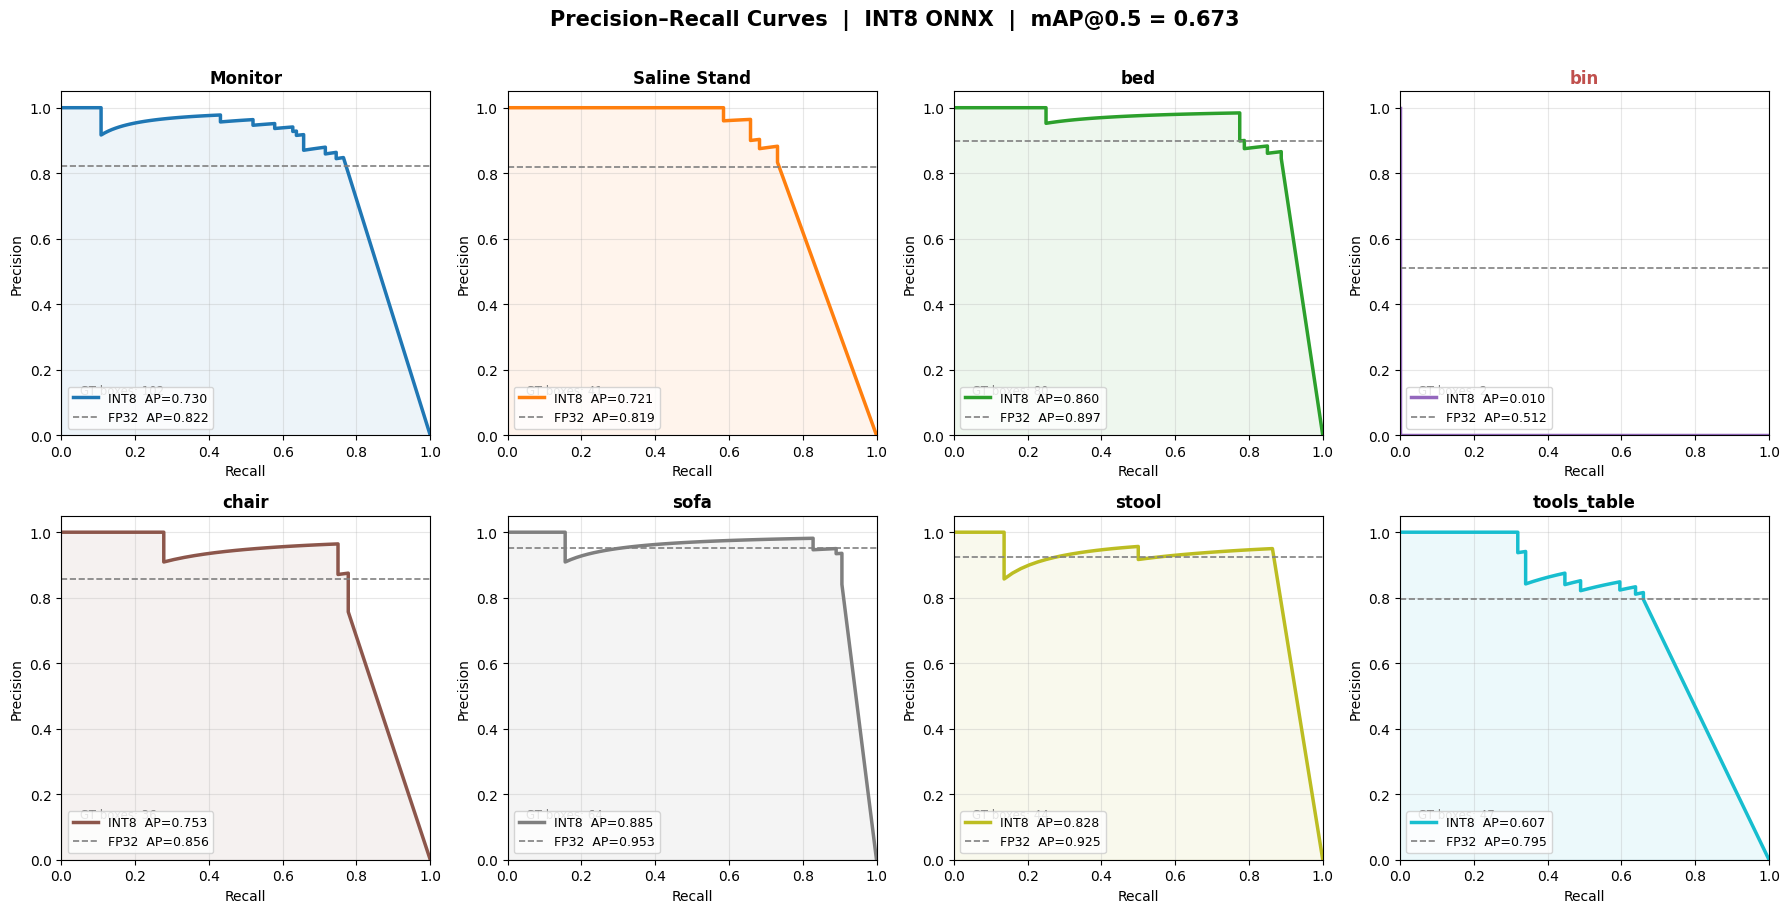

Saved: pr_curves.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def get_pr_curve(pred_list, n_gt):
    if n_gt == 0 or not pred_list:
        return [0,1], [0,0], 0.0
    pred_list = sorted(pred_list, key=lambda x: -x[0])
    tp_c = fp_c = 0
    precs, recs = [1.0], [0.0]
    for _, tp in pred_list:
        if tp: tp_c += 1
        else:  fp_c += 1
        precs.append(tp_c / (tp_c + fp_c))
        recs.append(tp_c / n_gt)
    precs.append(0.0)
    recs.append(1.0)
    ap = sum(
        max((precs[k] for k, r in enumerate(recs) if r >= t), default=0)
        for t in np.linspace(0, 1, 101)
    ) / 101
    return recs, precs, ap

COLORS = plt.cm.tab10(np.linspace(0, 1, NC))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for c, (name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    recs, precs, ap = get_pr_curve(all_preds[c], all_gt_cnt[c])
    fp32_ap = fp32.get(name, 0)

    ax.plot(recs, precs, color=COLORS[c], lw=2.5, label=f'INT8  AP={ap:.3f}')
    ax.axhline(fp32_ap, color='gray', lw=1.2, ls='--',
               label=f'FP32  AP={fp32_ap:.3f}')
    ax.fill_between(recs, precs, alpha=0.08, color=COLORS[c])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_xlabel('Recall',    fontsize=10)
    ax.set_ylabel('Precision', fontsize=10)
    ax.set_title(name, fontsize=12, fontweight='bold',
                 color='#C0504D' if name == 'bin' else 'black')
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.12, f'GT boxes: {all_gt_cnt[c]}',
            transform=ax.transAxes, fontsize=8.5, color='gray')

fig.suptitle(
    f'Precision–Recall Curves  |  INT8 ONNX  |  mAP@0.5 = {mAP:.3f}',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('/kaggle/working/pr_curves.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: pr_curves.png")

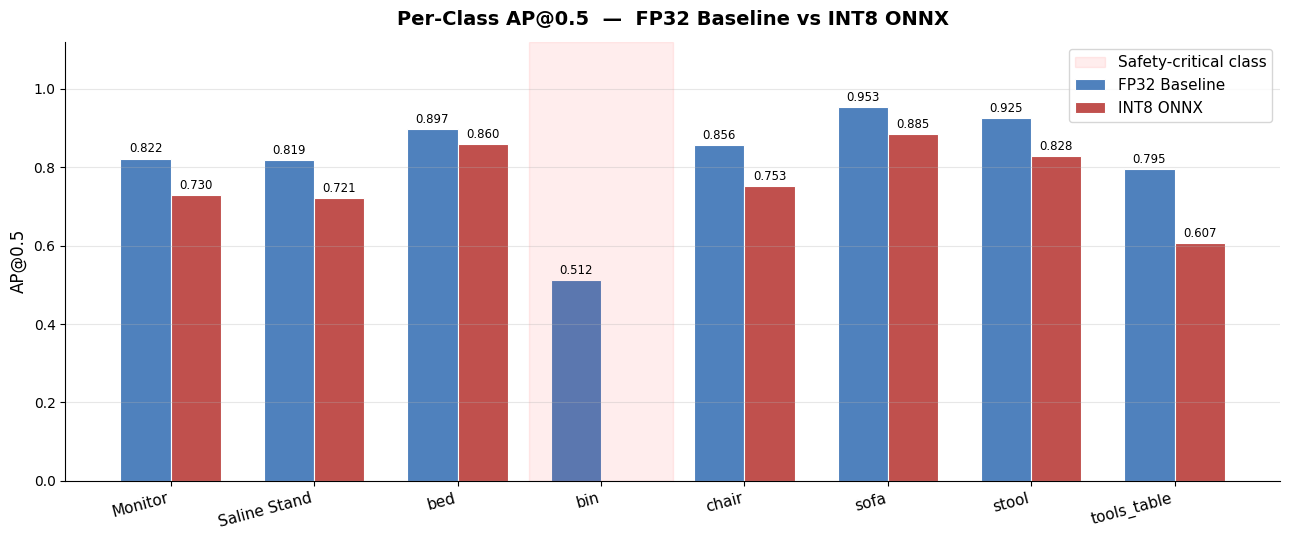

Saved: ap_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x    = np.arange(NC)
w    = 0.35
fp32_vals = [fp32.get(n, 0) for n in CLASS_NAMES]

bars1 = ax.bar(x - w/2, fp32_vals, w, label='FP32 Baseline',
               color='#4F81BD', edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + w/2, aps,       w, label='INT8 ONNX',
               color='#C0504D', edgecolor='white', linewidth=0.8)

# Value labels on top of bars
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5)

# Highlight bin class background
bin_idx = CLASS_NAMES.index('bin')
ax.axvspan(bin_idx - 0.5, bin_idx + 0.5, alpha=0.07,
           color='red', label='Safety-critical class')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11, rotation=15, ha='right')
ax.set_ylabel('AP@0.5', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Per-Class AP@0.5  —  FP32 Baseline vs INT8 ONNX',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/ap_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: ap_comparison.png")

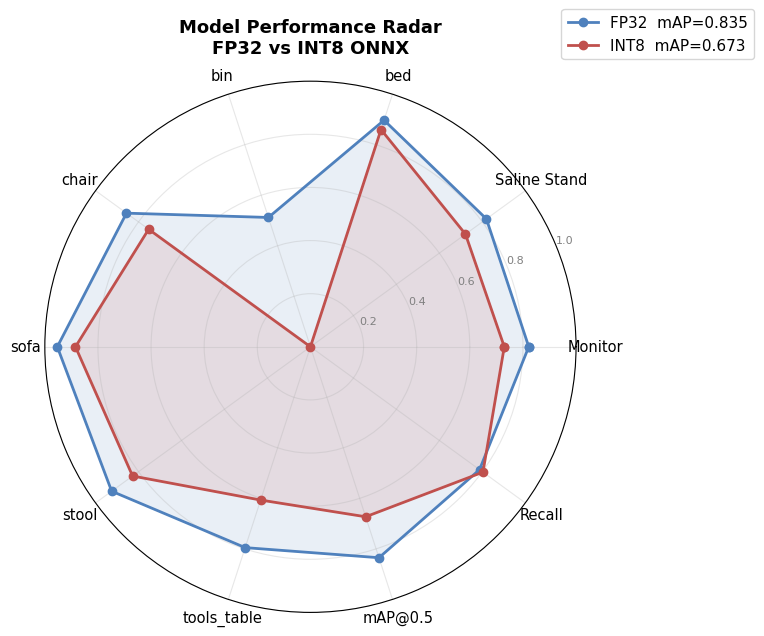

Saved: radar_chart.png


In [11]:
from matplotlib.patches import FancyBboxPatch

# Normalised scores for radar (relative to FP32 = 1.0)
labels_radar = CLASS_NAMES + ['mAP@0.5', 'Recall']
fp32_radar   = [fp32.get(n, 0) for n in CLASS_NAMES] + [fp32['mAP@0.5'], fp32['Recall']]
int8_radar   = aps + [mAP, recall]

N    = len(labels_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fp32_vals_r = [v for v in fp32_radar] + [fp32_radar[0]]
int8_vals_r = [v for v in int8_radar] + [int8_radar[0]]

fig, ax = plt.subplots(figsize=(8, 8),
                       subplot_kw=dict(polar=True))
ax.plot(angles, fp32_vals_r, 'o-', lw=2, color='#4F81BD',
        label=f'FP32  mAP={fp32["mAP@0.5"]:.3f}')
ax.fill(angles, fp32_vals_r, alpha=0.12, color='#4F81BD')

ax.plot(angles, int8_vals_r, 'o-', lw=2, color='#C0504D',
        label=f'INT8  mAP={mAP:.3f}')
ax.fill(angles, int8_vals_r, alpha=0.12, color='#C0504D')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=10.5)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color='gray')
ax.grid(True, alpha=0.3)
ax.set_title('Model Performance Radar\nFP32 vs INT8 ONNX',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/radar_chart.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: radar_chart.png")

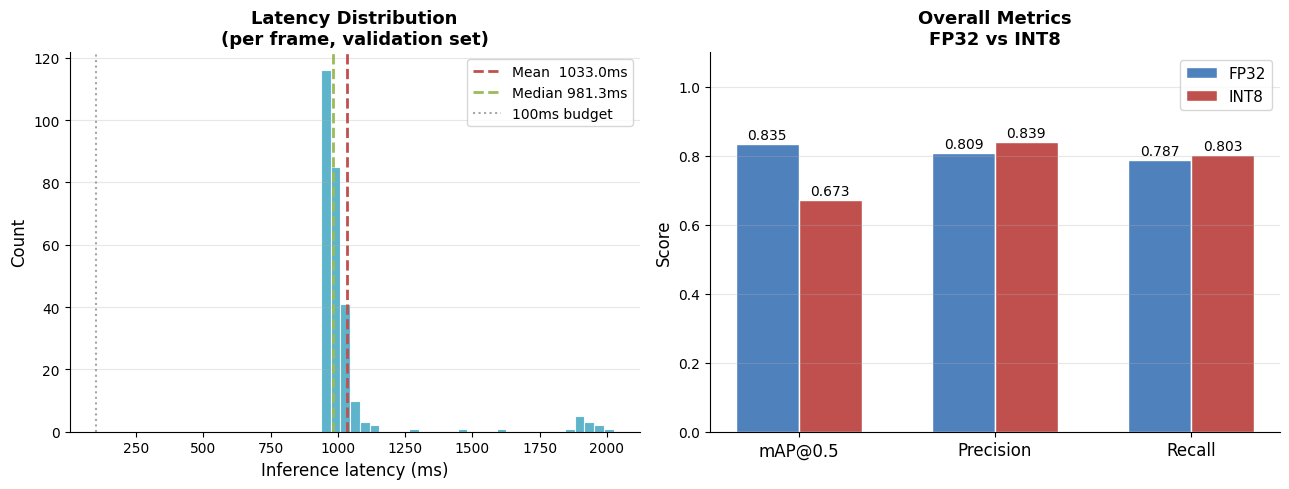

Saved: latency_and_metrics.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: latency distribution ──
ax1.hist(latencies, bins=30, color='#4BACC6', edgecolor='white',
         linewidth=0.8, alpha=0.9)
ax1.axvline(np.mean(latencies),   color='#C0504D', lw=2,
            ls='--', label=f'Mean  {np.mean(latencies):.1f}ms')
ax1.axvline(np.median(latencies), color='#9BBB59', lw=2,
            ls='--', label=f'Median {np.median(latencies):.1f}ms')
ax1.axvline(100, color='gray', lw=1.5, ls=':', alpha=0.7,
            label='100ms budget')
ax1.set_xlabel('Inference latency (ms)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Latency Distribution\n(per frame, validation set)',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# ── Right: summary metrics bar chart ──
metrics_labels = ['mAP@0.5', 'Precision', 'Recall']
fp32_vals_m    = [fp32['mAP@0.5'], fp32['Precision'], fp32['Recall']]
int8_vals_m    = [mAP, precision, recall]
x2 = np.arange(3)
w2 = 0.32

b1 = ax2.bar(x2 - w2/2, fp32_vals_m, w2,
             color='#4F81BD', label='FP32', edgecolor='white')
b2 = ax2.bar(x2 + w2/2, int8_vals_m, w2,
             color='#C0504D', label='INT8', edgecolor='white')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.005,
             f'{h:.3f}', ha='center', va='bottom', fontsize=10)

ax2.set_xticks(x2)
ax2.set_xticklabels(metrics_labels, fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Overall Metrics\nFP32 vs INT8',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/latency_and_metrics.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: latency_and_metrics.png")

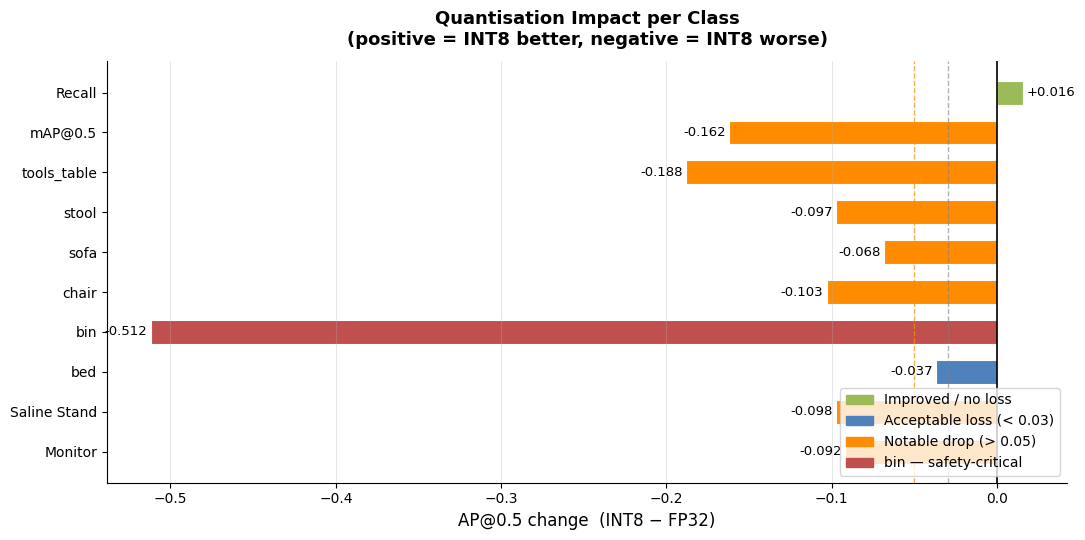

Saved: quantisation_impact.png


In [13]:
fig, ax = plt.subplots(figsize=(11, 5.5))

names_all  = CLASS_NAMES + ['mAP@0.5', 'Recall']
fp32_all   = [fp32.get(n, 0) for n in CLASS_NAMES] + \
             [fp32['mAP@0.5'], fp32['Recall']]
int8_all   = aps + [mAP, recall]
deltas     = [i - f for i, f in zip(int8_all, fp32_all)]

bar_colors = []
for i, (name, d) in enumerate(zip(names_all, deltas)):
    if name == 'bin':
        bar_colors.append('#C0504D')     # red — safety-critical
    elif d < -0.05:
        bar_colors.append('#FF8C00')     # orange — notable drop
    elif d >= 0:
        bar_colors.append('#9BBB59')     # green — improvement
    else:
        bar_colors.append('#4F81BD')     # blue — acceptable loss

bars = ax.barh(names_all, deltas, color=bar_colors,
               edgecolor='white', linewidth=0.8, height=0.6)

ax.axvline(0,    color='black', lw=1.2)
ax.axvline(-0.03, color='gray', lw=1, ls='--', alpha=0.6,
           label='−0.03 acceptable threshold')
ax.axvline(-0.05, color='#FF8C00', lw=1, ls='--', alpha=0.7,
           label='−0.05 concern threshold')

for bar, d in zip(bars, deltas):
    xpos = d + 0.002 if d >= 0 else d - 0.002
    ha   = 'left' if d >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{d:+.3f}', va='center', ha=ha, fontsize=9.5)

ax.set_xlabel('AP@0.5 change  (INT8 − FP32)', fontsize=12)
ax.set_title('Quantisation Impact per Class\n(positive = INT8 better, negative = INT8 worse)',
             fontsize=13, fontweight='bold', pad=12)

legend_patches = [
    mpatches.Patch(color='#9BBB59',  label='Improved / no loss'),
    mpatches.Patch(color='#4F81BD',  label='Acceptable loss (< 0.03)'),
    mpatches.Patch(color='#FF8C00',  label='Notable drop (> 0.05)'),
    mpatches.Patch(color='#C0504D',  label='bin — safety-critical'),
]
ax.legend(handles=legend_patches, fontsize=10,
          loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/quantisation_impact.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: quantisation_impact.png")

In [14]:
import csv

rows = []
for c, name in enumerate(CLASS_NAMES):
    rows.append({
        'class':      name,
        'gt_boxes':   all_gt_cnt[c],
        'n_preds':    len(all_preds[c]),
        'ap_fp32':    round(fp32.get(name, 0), 4),
        'ap_int8':    round(aps[c], 4),
        'delta':      round(aps[c] - fp32.get(name, 0), 4),
    })

# Summary rows
rows.append({'class': 'mAP@0.5',   'ap_fp32': fp32['mAP@0.5'],
             'ap_int8': round(mAP,4),
             'delta': round(mAP - fp32['mAP@0.5'], 4)})
rows.append({'class': 'Precision',  'ap_fp32': fp32['Precision'],
             'ap_int8': round(precision,4),
             'delta': round(precision - fp32['Precision'], 4)})
rows.append({'class': 'Recall',     'ap_fp32': fp32['Recall'],
             'ap_int8': round(recall,4),
             'delta': round(recall - fp32['Recall'], 4)})
rows.append({'class': 'mean_latency_ms', 'ap_int8': round(np.mean(latencies),2)})
rows.append({'class': 'p95_latency_ms',  'ap_int8': round(np.percentile(latencies,95),2)})
rows.append({'class': 'fps_estimate',    'ap_int8': round(1000/np.mean(latencies),1)})

csv_path = '/kaggle/working/int8_eval_results.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f,
        fieldnames=['class','gt_boxes','n_preds','ap_fp32','ap_int8','delta'])
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved: {csv_path}")
print("\nAll output files in /kaggle/working/:")
for f in sorted(Path('/kaggle/working').glob('*')):
    size = f.stat().st_size // 1024
    print(f"  {f.name:<35} {size:>5} KB")

Saved: /kaggle/working/int8_eval_results.csv

All output files in /kaggle/working/:
  __notebook__.ipynb                    612 KB
  ap_comparison.png                      85 KB
  int8_eval_results.csv                   0 KB
  latency_and_metrics.png                86 KB
  pr_curves.png                         202 KB
  quantisation_impact.png                92 KB
  radar_chart.png                       181 KB
